# Notebook 3: Regression Models — Training & Evaluation

## California Housing Prices

**Goal**: Train multiple regression models and compare their performance.

Data Science Lifecycle:
1. Data Loading ✅
2. Exploratory Data Analysis ✅
3. Preprocessing & Feature Engineering ✅
4. **Model Training & Evaluation** ← we are here
5. Model Comparison & Insights

---

### Models we'll train:
1. Linear Regression (baseline)
2. Ridge Regression (L2 regularization)
3. Lasso Regression (L1 regularization)
4. Decision Tree Regressor
5. Random Forest Regressor
6. XGBoost Regressor

### Metrics we'll use:
- **MAE** (Mean Absolute Error): Average error in the same units as the target
- **MSE** (Mean Squared Error): Penalizes larger errors more heavily
- **RMSE** (Root MSE): Same as MSE but in original units
- **R²** (R-squared): How much variance the model explains (1.0 = perfect)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


In [2]:
# load preprocessed data
X_train = pd.read_csv('../data/X_train_reg.csv')
X_test = pd.read_csv('../data/X_test_reg.csv')
y_train = pd.read_csv('../data/y_train_reg.csv').squeeze()
y_test = pd.read_csv('../data/y_test_reg.csv').squeeze()

# also load unscaled for tree-based models
X_train_raw = pd.read_csv('../data/X_train_reg_unscaled.csv')
X_test_raw = pd.read_csv('../data/X_test_reg_unscaled.csv')

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')
print(f'Features: {X_train.shape[1]}')

Training samples: 15718
Test samples: 3930
Features: 10


## Helper Function

Let's create a simple function to evaluate models consistently.

In [3]:
# helper function to evaluate a model
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):
    """Train a model, make predictions, and return metrics."""
    # train
    model.fit(X_tr, y_tr)
    
    # predict on both sets
    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)
    
    # calculate metrics
    results = {
        'Model': name,
        'Train MAE': mean_absolute_error(y_tr, train_pred),
        'Test MAE': mean_absolute_error(y_te, test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_tr, train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_te, test_pred)),
        'Train R²': r2_score(y_tr, train_pred),
        'Test R²': r2_score(y_te, test_pred)
    }
    
    return results, test_pred

# store all results
all_results = []
all_predictions = {}
print('Helper function ready!')

Helper function ready!


## Model 1: Linear Regression (Baseline)

**What it does**: Finds the best straight line (or hyperplane) through the data.

**When to use**: Good starting point. Works well when the relationship between features and target is roughly linear.

**Strengths**: Simple, fast, interpretable.
**Weaknesses**: Can't capture complex, non-linear patterns.

In [4]:
# Model 1: Linear Regression
lr = LinearRegression()
results, preds = evaluate_model(lr, X_train, X_test, y_train, y_test, 'Linear Regression')
all_results.append(results)
all_predictions['Linear Regression'] = preds

print('Linear Regression Results:')
for key, val in results.items():
    if key != 'Model':
        print(f'  {key}: {val:.4f}')

Linear Regression Results:
  Train MAE: 0.4264
  Test MAE: 0.4429
  Train RMSE: 0.5792
  Test RMSE: 0.5979
  Train R²: 0.6428
  Test R²: 0.6272


## Model 2: Ridge Regression (L2 Regularization)

**What it does**: Same as Linear Regression, but adds a penalty for large coefficients.
This helps prevent overfitting.

**When to use**: When you have many features and want to prevent the model from
relying too heavily on any single feature.

**Key parameter**: `alpha` — controls the strength of regularization. Higher = more penalty.

In [5]:
# Model 2: Ridge Regression
ridge = Ridge(alpha=1.0)
results, preds = evaluate_model(ridge, X_train, X_test, y_train, y_test, 'Ridge Regression')
all_results.append(results)
all_predictions['Ridge Regression'] = preds

print('Ridge Regression Results:')
for key, val in results.items():
    if key != 'Model':
        print(f'  {key}: {val:.4f}')

Ridge Regression Results:
  Train MAE: 0.4264
  Test MAE: 0.4429
  Train RMSE: 0.5792
  Test RMSE: 0.5979
  Train R²: 0.6428
  Test R²: 0.6272


## Model 3: Lasso Regression (L1 Regularization)

**What it does**: Similar to Ridge, but can actually set some feature coefficients to zero.
This means it does automatic feature selection!

**When to use**: When you suspect some features are irrelevant and want the model
to ignore them automatically.

**Key difference from Ridge**: Lasso can eliminate features entirely; Ridge just shrinks them.

In [6]:
# Model 3: Lasso Regression
lasso = Lasso(alpha=0.001)
results, preds = evaluate_model(lasso, X_train, X_test, y_train, y_test, 'Lasso Regression')
all_results.append(results)
all_predictions['Lasso Regression'] = preds

print('Lasso Regression Results:')
for key, val in results.items():
    if key != 'Model':
        print(f'  {key}: {val:.4f}')

# show which features Lasso kept
print('\nFeature coefficients (Lasso):')
coefs = pd.Series(lasso.coef_, index=X_train.columns)
print(coefs.round(4))
print(f'\nFeatures set to zero: {(coefs == 0).sum()}')

Lasso Regression Results:
  Train MAE: 0.4265
  Test MAE: 0.4432
  Train RMSE: 0.5792
  Test RMSE: 0.5981
  Train R²: 0.6427
  Test R²: 0.6269

Feature coefficients (Lasso):
MedInc            0.6380
HouseAge          0.1272
AveRooms         -0.0262
AveBedrms        -0.0110
Population        0.0550
AveOccup         -0.1062
Latitude         -0.8263
Longitude        -0.7663
BedroomRatio      0.2050
RoomsPerPerson    0.1991
dtype: float64

Features set to zero: 0


## Model 4: Decision Tree Regressor

**What it does**: Splits the data into regions based on feature values, like a flowchart.
Each leaf node gives a prediction.

**When to use**: When the relationship is non-linear. Great for understanding feature importance.

**Strengths**: Handles non-linear data, no scaling needed, easy to visualize.
**Weaknesses**: Prone to overfitting (memorizes training data).

**Note**: Tree-based models don't need scaled features, so we use the raw data.

In [7]:
# Model 4: Decision Tree (using unscaled data)
dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, random_state=42)
results, preds = evaluate_model(dt, X_train_raw, X_test_raw, y_train, y_test, 'Decision Tree')
all_results.append(results)
all_predictions['Decision Tree'] = preds

print('Decision Tree Results:')
for key, val in results.items():
    if key != 'Model':
        print(f'  {key}: {val:.4f}')

# notice the gap between train and test — sign of overfitting?
gap = results['Train R²'] - results['Test R²']
print(f'\nTrain-Test R² gap: {gap:.4f} (smaller is better)')

Decision Tree Results:
  Train MAE: 0.3143
  Test MAE: 0.3884
  Train RMSE: 0.4482
  Test RMSE: 0.5660
  Train R²: 0.7861
  Test R²: 0.6658

Train-Test R² gap: 0.1202 (smaller is better)


## Model 5: Random Forest Regressor

**What it does**: Trains many decision trees on random subsets of the data,
then averages their predictions. This reduces overfitting.

**When to use**: Almost always a strong choice. Works well on most tabular data.

**Strengths**: Handles non-linear data, resistant to overfitting, gives feature importance.
**Weaknesses**: Slower to train, harder to interpret than a single tree.

In [8]:
# Model 5: Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, 
                           min_samples_leaf=5, random_state=42, n_jobs=-1)
results, preds = evaluate_model(rf, X_train_raw, X_test_raw, y_train, y_test, 'Random Forest')
all_results.append(results)
all_predictions['Random Forest'] = preds

print('Random Forest Results:')
for key, val in results.items():
    if key != 'Model':
        print(f'  {key}: {val:.4f}')

Random Forest Results:
  Train MAE: 0.2044
  Test MAE: 0.3192
  Train RMSE: 0.3094
  Test RMSE: 0.4734
  Train R²: 0.8981
  Test R²: 0.7663


## Model 6: XGBoost Regressor

**What it does**: Builds trees one at a time, where each new tree tries to fix
the mistakes of the previous ones. This is called "boosting".

**When to use**: When you want top performance on tabular data. Often wins competitions.

**Strengths**: Very accurate, handles missing values, built-in regularization.
**Weaknesses**: More hyperparameters to tune, can overfit if not careful.

In [9]:
# Model 6: XGBoost
xgb = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                    random_state=42, n_jobs=-1, verbosity=0)
results, preds = evaluate_model(xgb, X_train_raw, X_test_raw, y_train, y_test, 'XGBoost')
all_results.append(results)
all_predictions['XGBoost'] = preds

print('XGBoost Results:')
for key, val in results.items():
    if key != 'Model':
        print(f'  {key}: {val:.4f}')

XGBoost Results:
  Train MAE: 0.1952
  Test MAE: 0.2852
  Train RMSE: 0.2753
  Test RMSE: 0.4241
  Train R²: 0.9193
  Test R²: 0.8124


## Results Comparison

Let's put all models side by side.

In [10]:
# create a comparison table
results_df = pd.DataFrame(all_results)
results_df = results_df.set_index('Model')
results_df = results_df.round(4)

# sort by Test R² (higher is better)
results_df = results_df.sort_values('Test R²', ascending=False)
print('Model Comparison (sorted by Test R²):')
results_df

Model Comparison (sorted by Test R²):


,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
Model,,,,,,
XGBoost,0.1952,0.2852,0.2753,0.4241,0.9193,0.8124
Random Forest,0.2044,0.3192,0.3094,0.4734,0.8981,0.7663
Decision Tree,0.3143,0.3884,0.4482,0.5660,0.7861,0.6658
Linear Regression,0.4264,0.4429,0.5792,0.5979,0.6428,0.6272
Ridge Regression,0.4264,0.4429,0.5792,0.5979,0.6428,0.6272
Lasso Regression,0.4265,0.4432,0.5792,0.5981,0.6427,0.6269


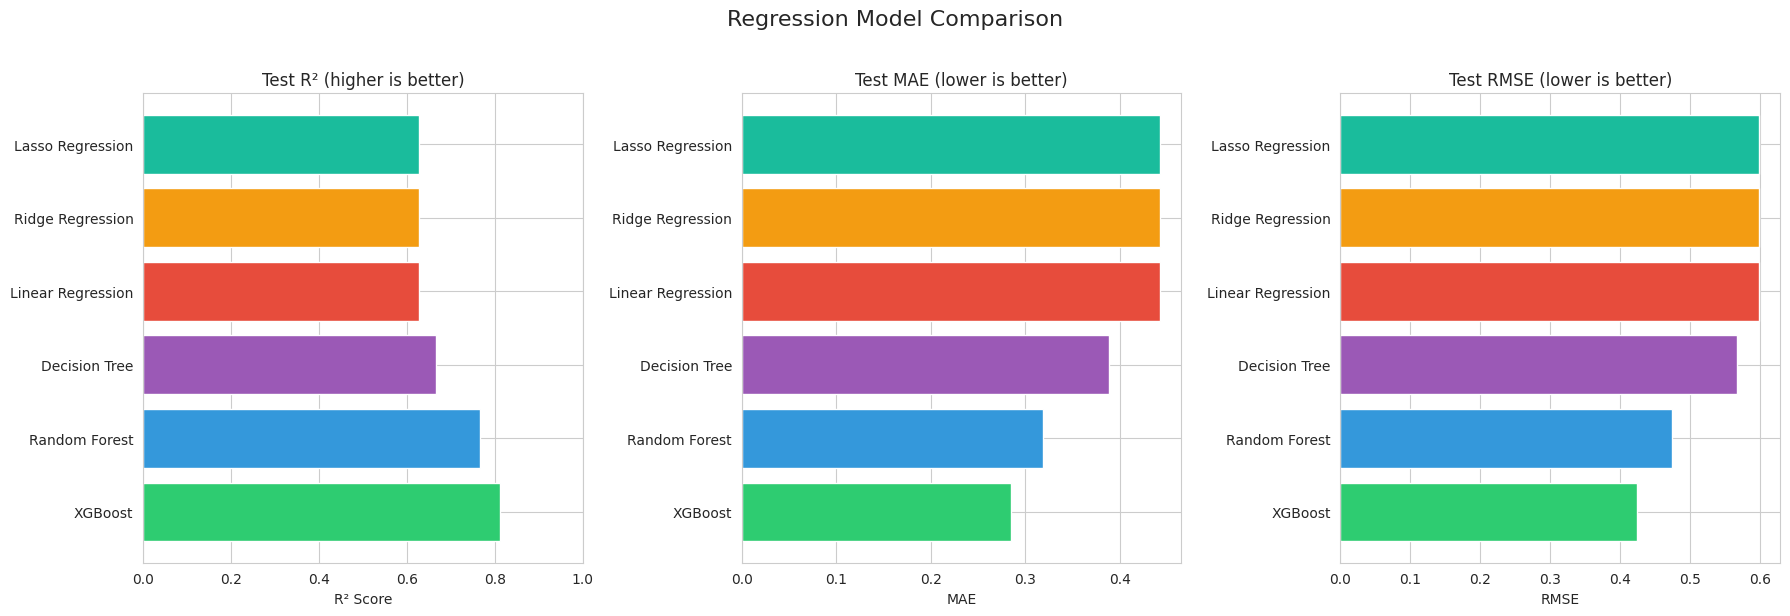

In [11]:
# visualize the comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = results_df.index.tolist()
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c']

# Test R²
axes[0].barh(models, results_df['Test R²'], color=colors)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Test R² (higher is better)')
axes[0].set_xlim(0, 1)

# Test MAE
axes[1].barh(models, results_df['Test MAE'], color=colors)
axes[1].set_xlabel('MAE')
axes[1].set_title('Test MAE (lower is better)')

# Test RMSE
axes[2].barh(models, results_df['Test RMSE'], color=colors)
axes[2].set_xlabel('RMSE')
axes[2].set_title('Test RMSE (lower is better)')

plt.suptitle('Regression Model Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cross-Validation

**Why cross-validation?** A single train-test split can be "lucky" or "unlucky".
Cross-validation splits the data multiple times and averages the results,
giving us a more reliable estimate of model performance.

We'll use 5-fold CV on our top 3 models.

In [12]:
# cross-validation for top models
cv_models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, 
                                           min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                            random_state=42, n_jobs=-1, verbosity=0),
    'Linear Regression': LinearRegression()
}

print('5-Fold Cross-Validation Results (R² Score):')
print('-' * 50)

cv_results = []
for name, model in cv_models.items():
    # use raw data for tree models, scaled for linear
    data = X_train if name == 'Linear Regression' else X_train_raw
    scores = cross_val_score(model, data, y_train, cv=5, scoring='r2')
    cv_results.append({'Model': name, 'Mean R²': scores.mean(), 'Std R²': scores.std()})
    print(f'{name:25s} | Mean R²: {scores.mean():.4f} ± {scores.std():.4f}')

print('\nCross-validation confirms our results are stable, not just lucky!')

5-Fold Cross-Validation Results (R² Score):
--------------------------------------------------


Random Forest             | Mean R²: 0.7662 ± 0.0065


XGBoost                   | Mean R²: 0.8130 ± 0.0080
Linear Regression         | Mean R²: 0.6410 ± 0.0138

Cross-validation confirms our results are stable, not just lucky!


## Feature Importance

Let's see which features matter most according to our best model.

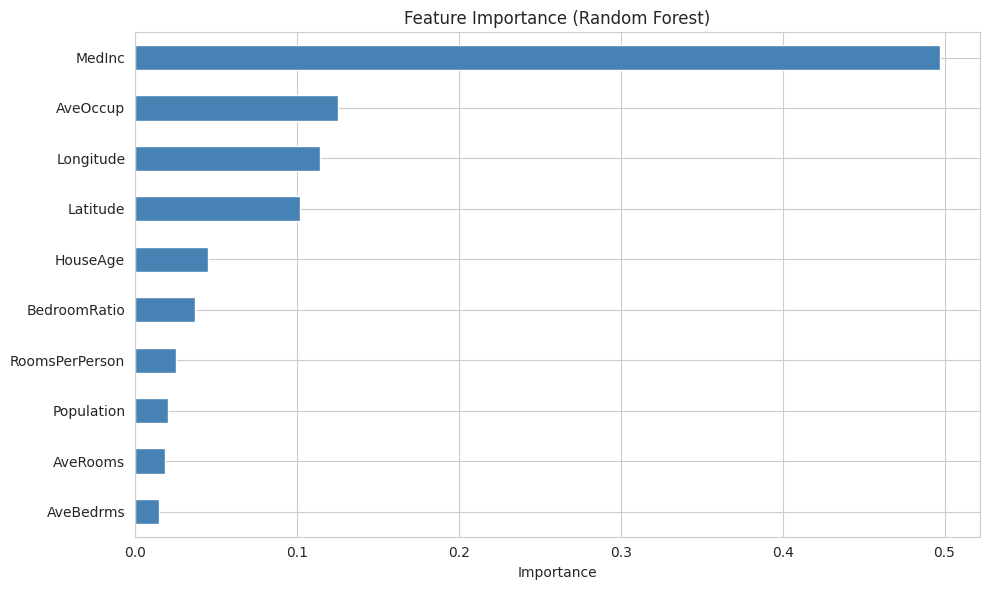

Top 3 most important features:
  Longitude: 0.1142
  AveOccup: 0.1252
  MedInc: 0.4971


In [13]:
# feature importance from Random Forest
feature_imp = pd.Series(rf.feature_importances_, index=X_train_raw.columns)
feature_imp = feature_imp.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../images/03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 3 most important features:')
for feat, imp in feature_imp.tail(3).items():
    print(f'  {feat}: {imp:.4f}')

## Actual vs Predicted (Best Model)

Let's visualize how well our best model's predictions match reality.

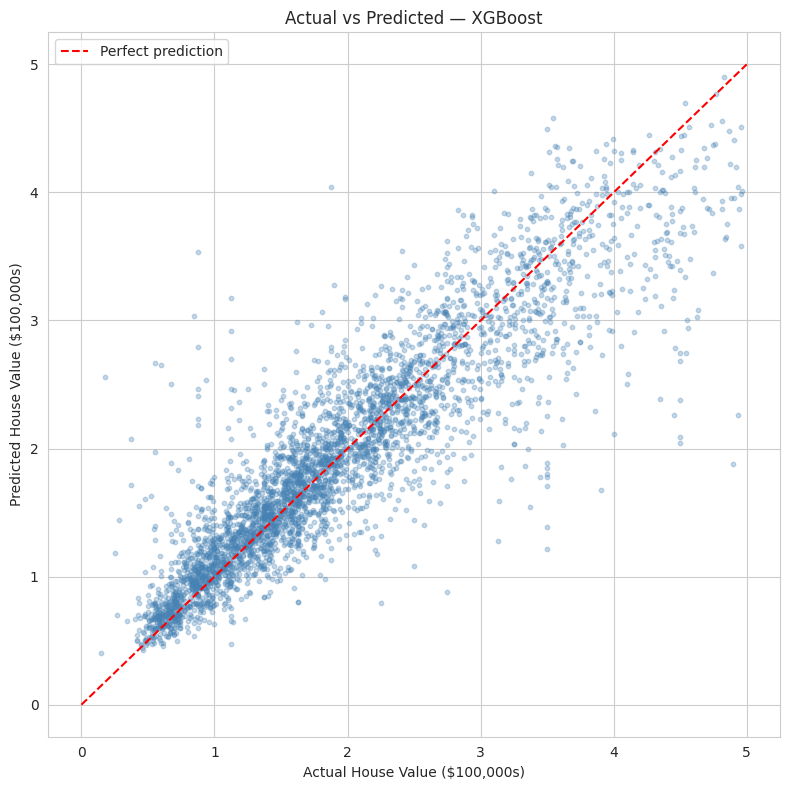

Points closer to the red line = better predictions


In [14]:
# actual vs predicted for the best model
best_model_name = results_df.index[0]  # first row after sorting by Test R²
best_preds = all_predictions[best_model_name]

plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_preds, alpha=0.3, s=10, color='steelblue')
plt.plot([0, 5], [0, 5], 'r--', label='Perfect prediction')
plt.xlabel('Actual House Value ($100,000s)')
plt.ylabel('Predicted House Value ($100,000s)')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.savefig('../images/03_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Points closer to the red line = better predictions')

## Overfitting Check

**Overfitting** = model performs great on training data but poorly on test data.
It memorized the training data instead of learning general patterns.

Let's check the gap between train and test performance.

In [15]:
# overfitting analysis
overfit_df = results_df[['Train R²', 'Test R²']].copy()
overfit_df['Gap'] = overfit_df['Train R²'] - overfit_df['Test R²']
overfit_df['Overfitting?'] = overfit_df['Gap'].apply(
    lambda x: 'Yes ⚠️' if x > 0.05 else 'Minimal ✅'
)

print('Overfitting Analysis:')
overfit_df.round(4)

Overfitting Analysis:


,Train R²,Test R²,Gap,Overfitting?
Model,,,,
XGBoost,0.9193,0.8124,0.1069,Yes ⚠️
Random Forest,0.8981,0.7663,0.1318,Yes ⚠️
Decision Tree,0.7861,0.6658,0.1203,Yes ⚠️
Linear Regression,0.6428,0.6272,0.0156,Minimal ✅
Ridge Regression,0.6428,0.6272,0.0156,Minimal ✅
Lasso Regression,0.6427,0.6269,0.0158,Minimal ✅


## Save the Results

Let's save our comparison table for the final summary notebook.

In [16]:
# save results
results_df.to_csv('../data/regression_results.csv')
print('Regression results saved!')
print(f'\nBest model: {results_df.index[0]} with Test R² = {results_df["Test R²"].iloc[0]:.4f}')

Regression results saved!

Best model: XGBoost with Test R² = 0.8124


## Key Takeaways

1. **Tree-based models** (Random Forest, XGBoost) outperformed linear models on this dataset
2. **MedInc (Median Income)** is by far the most important feature
3. **Regularization** (Ridge/Lasso) didn't help much here — the dataset isn't very high-dimensional
4. **Decision Trees** tend to overfit more than Random Forests (ensemble = better generalization)
5. **Cross-validation** confirmed our results are reliable

### Next Steps
Now let's move to a **classification** problem with a different dataset!